In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')


In [9]:
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
# Clean stock symbols: uppercase and remove spaces
news_df['stock'] = news_df['stock'].str.upper().str.strip()

# Create a column with headline length (number of characters)
news_df['headline_len'] = news_df['headline'].apply(lambda x: len(str(x)))

In [10]:
def get_top_bigrams(corpus, n=10):
    """
    Find the most common 2-word phrases in headlines
    corpus = all your headlines
    n = how many top phrases to return
    """
    # Create a tool that finds 2-word phrases
    vec = CountVectorizer(stop_words='english', ngram_range=(2, 2))
    
    # Convert headlines to numbers
    bag_of_words = vec.fit_transform(corpus)
    
    # Count how many times each phrase appears
    sum_words = bag_of_words.sum(axis=0)
    
    # Create list of (phrase, count) pairs
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    # Sort by count (highest first) and return top n
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Remove any empty headlines
clean_headlines = news_df['headline'].dropna()

# Get top 10 phrases
top_phrases = get_top_bigrams(clean_headlines)

# Display the phrases
print("\n=== TOP 10 COMMON PHRASES ===")
for phrase, count in top_phrases:
    print(f"{phrase}: {count} times")


=== TOP 10 COMMON PHRASES ===
52 week: 51006 times
price target: 47274 times
stocks moving: 40044 times
mid day: 37324 times
market update: 33101 times
earnings scheduled: 32055 times
initiates coverage: 28993 times
pre market: 28393 times
raises pt: 27213 times
companies trading: 23170 times


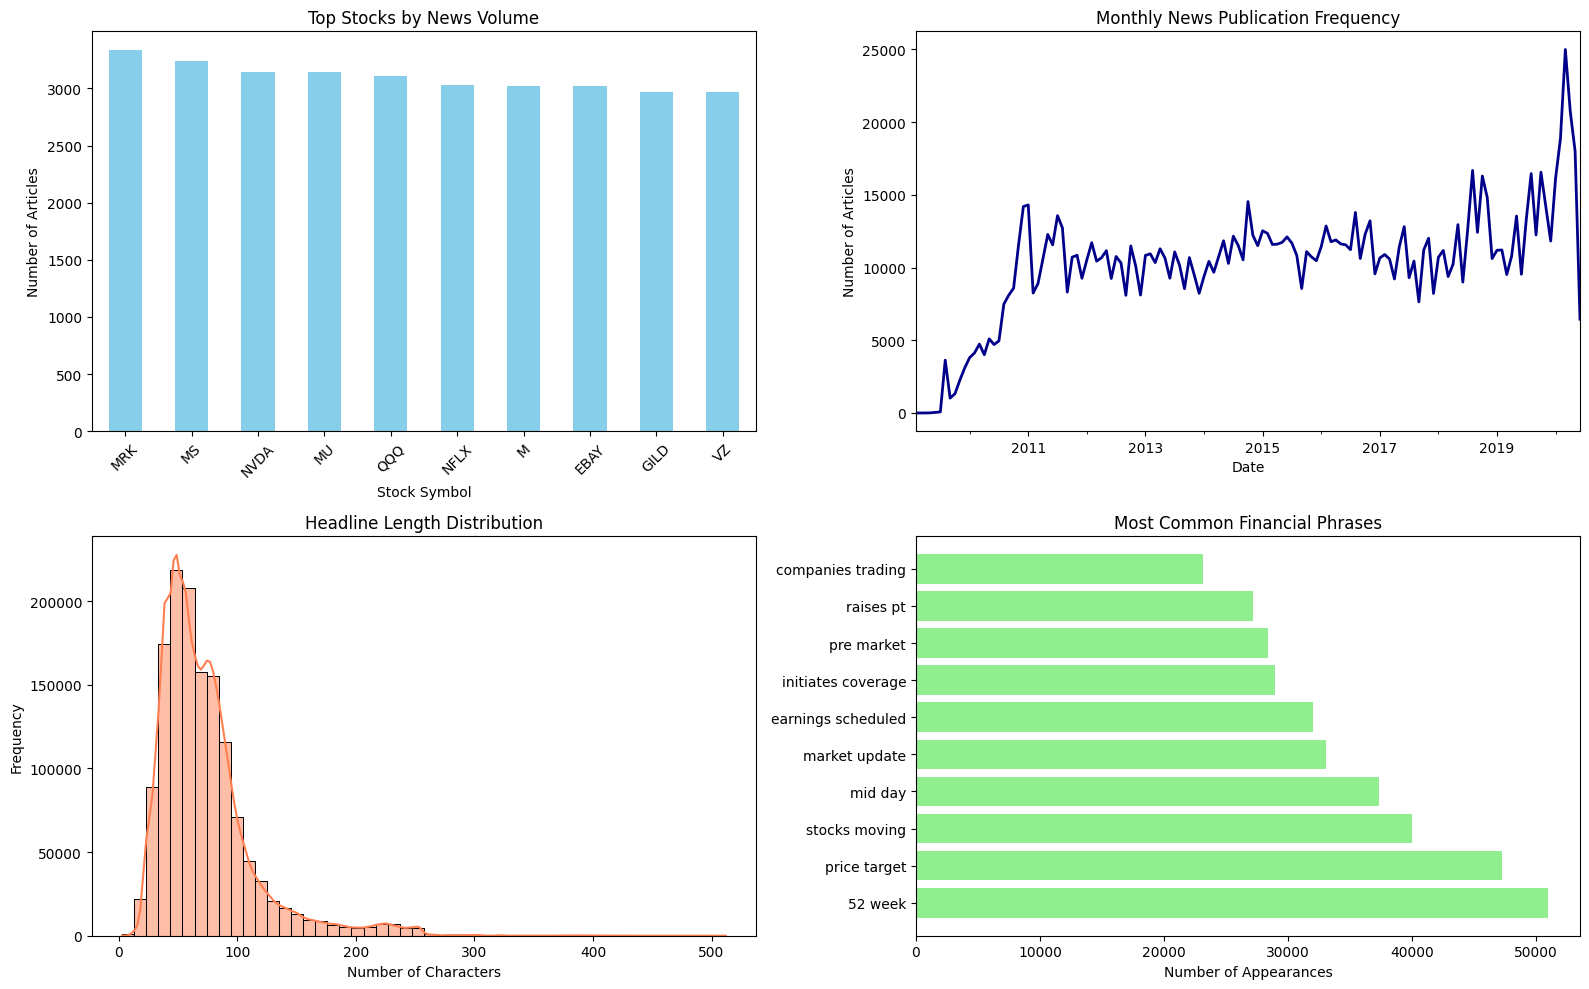

In [11]:
# Create one big figure with 4 charts
plt.figure(figsize=(16, 10))

# CHART 1: Top Stocks by News Volume (Top-Left)
plt.subplot(2, 2, 1)
news_df['stock'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top Stocks by News Volume', fontsize=12)
plt.xlabel('Stock Symbol')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)

# CHART 2: Monthly News Trend (Top-Right)
plt.subplot(2, 2, 2)
news_df.set_index('date').resample('ME').size().plot(color='darkblue', linewidth=2)
plt.title('Monthly News Publication Frequency', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Number of Articles')

# CHART 3: Headline Length Distribution (Bottom-Left)
plt.subplot(2, 2, 3)
sns.histplot(news_df['headline_len'], bins=50, kde=True, color='coral')
plt.title('Headline Length Distribution', fontsize=12)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

# CHART 4: Most Common Phrases (Bottom-Right)
plt.subplot(2, 2, 4)
words, counts = zip(*top_phrases)
plt.barh(words, counts, color='lightgreen')
plt.title('Most Common Financial Phrases', fontsize=12)
plt.xlabel('Number of Appearances')

# Adjust spacing so nothing overlaps
plt.tight_layout()

# Save the chart as an image file
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')

# Display the chart
plt.show()

In [12]:
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

print(f"Total articles: {len(news_df)}")
print(f"Date range: {news_df['date'].min().date()} to {news_df['date'].max().date()}")
print(f"Unique stocks: {news_df['stock'].nunique()}")
print(f"Unique publishers: {news_df['publisher'].nunique()}")

print(f"\nAverage headline length: {news_df['headline_len'].mean():.1f} characters")
print(f"Shortest headline: {news_df['headline_len'].min()} characters")
print(f"Longest headline: {news_df['headline_len'].max()} characters")

print(f"\nMost covered stock: {news_df['stock'].value_counts().index[0]} ({news_df['stock'].value_counts().iloc[0]} articles)")

print(f"\nBusiest month: {news_df.set_index('date').resample('ME').size().idxmax().strftime('%B %Y')}")


SUMMARY STATISTICS
Total articles: 1407328
Date range: 2009-02-14 to 2020-06-11
Unique stocks: 6204
Unique publishers: 1034

Average headline length: 73.1 characters
Shortest headline: 3 characters
Longest headline: 512 characters

Most covered stock: MRK (3333 articles)

Busiest month: March 2020
